# Van der Vusse CSTR case study (up to aggregated causal graph)

This notebook replicates the workflow style from `tutorials/case_studies/biogeoscience_case_study.ipynb`, but uses a **continuous-time** van der Vusse CSTR model.

Even though the model is given by differential equations, causal discovery is still possible by:

1. Simulating the ODE system,
2. Sampling trajectories at regular time intervals,
3. Applying lag-based causal discovery (PCMCIplus) to the sampled multivariate time series.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

import tigramite.data_processing as pp
import tigramite.plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr

In [2]:
# ---------------- User controls ----------------
# Set to False for a fully deterministic simulation (no process noise, no measurement noise).
USE_NOISE = False

# Noise amplitudes used only when USE_NOISE=True
THETA0_PROCESS_NOISE_STD = 0.2  # K
MEAS_NOISE_STD = {
    'cA': 0.015,
    'cB': 0.015,
    'theta': 0.08,
    'thetaK': 0.08,
    'theta0': 0.08,
}


## Data generation and plotting

We simulate the following (temperature-dependent) van der Vusse CSTR states:

- $c_A$: concentration of species A,
- $c_B$: concentration of species B,
- $\vartheta$: reactor temperature,
- $\vartheta_K$: coolant temperature.

Additionally we include the feed temperature $\vartheta_0(t)$ as an observed exogenous driver.

In [3]:
# ---------- Model parameters (requested nominal values) ----------
params = {
    # kinetic pre-exponentials
    "k10": 1.287e12,      # h^-1
    "k20": 1.287e12,      # h^-1
    "k30": 9.043e9,       # (mol_A * h)^-1
    # activation terms (Arrhenius exponent numerator, in K)
    "E1": -9758.3,
    "E2": -9758.3,
    "E3": -8560.0,
    # reaction enthalpies (kJ/mol)
    "dHrAB": 4.20,
    "dHrBC": -11.0,
    "dHrAD": -41.85,
    # thermo-physical and geometric parameters
    "rho": 0.9342,        # kg/L
    "Cp": 3.01,           # kJ/(kg*K)
    "kw": 4032.0,         # kJ/(h*m^2*K)
    "AR": 0.215,          # m^2
    "VR": 0.01,           # m^3
    "mK": 5.0,            # kg
    "CPK": 2.0,           # kJ/(kg*K)
    # operating values (used for simulation)
    "F": 0.01419,         # m^3/h
    "cA0": 5.1,           # mol/L
    "theta0_nom": 387.34, # K
    "Qk_nom": -1113.5,    # kJ/h
}

def rate_constants(theta, p):
    """Van der Vusse Arrhenius kinetics, theta in Kelvin."""
    k1 = p["k10"] * np.exp(p["E1"] / theta)
    k2 = p["k20"] * np.exp(p["E2"] / theta)
    k3 = p["k30"] * np.exp(p["E3"] / theta)
    return k1, k2, k3

def theta0_profile(t, p):
    # Exogenous feed-temperature disturbance around nominal value
    periodic = 1.5 * np.sin(2 * np.pi * t / 180.0) + 0.8 * np.sin(2 * np.pi * t / 420.0 + 0.7)
    return p["theta0_nom"] + periodic

def qk_profile(t, p):
    # Keep coolant heat flow fixed at nominal value for this tutorial
    return p["Qk_nom"]

def cstr_rhs(t, x, p, theta0_t):
    cA, cB, theta, thetaK = x

    theta0 = theta0_t
    Qk = qk_profile(t, p)
    k1, k2, k3 = rate_constants(theta, p)

    F_over_VR = p["F"] / p["VR"]
    rhoCp = p["rho"] * p["Cp"]
    rhoCpVR = rhoCp * (1000.0 * p["VR"])  # VR converted to L

    dcA = F_over_VR * (p["cA0"] - cA) - k1 * cA - k3 * cA**2
    dcB = -F_over_VR * cB + k1 * cA - k2 * cB

    reaction_heat = k1 * cA * p["dHrAB"] + k2 * cB * p["dHrBC"] + k3 * cA**2 * p["dHrAD"]

    dtheta = (
        F_over_VR * (theta0 - theta)
        - reaction_heat / rhoCp
        + (p["kw"] * p["AR"] / rhoCpVR) * (thetaK - theta)
    )

    dthetaK = (Qk + p["kw"] * p["AR"] * (theta - thetaK)) / (p["mK"] * p["CPK"])

    return np.array([dcA, dcB, dtheta, dthetaK])


In [4]:
# ---------- Generate multiple trajectories ----------
T = 1200
dt = 1.0
t_eval = np.arange(0, T, dt)

M = 8  # number of independent runs (similar role to multiple sites)

var_names = ["cA", "cB", "theta", "thetaK", "theta0"]
N = len(var_names)

data_dict = {}

for m in range(M):
    rng = np.random.default_rng(100 + m)

    # Initial conditions around a nominal operating point
    x0 = np.array([
        0.8 + 0.08 * rng.normal(),
        0.7 + 0.05 * rng.normal(),
        375 + 0.40 * rng.normal(),
        374 + 0.40 * rng.normal(),
    ])

    # Build an exogenous theta0 trajectory first (deterministic base + optional process noise)
    theta0 = np.array([theta0_profile(t, params) for t in t_eval])
    if USE_NOISE:
        theta0 = theta0 + THETA0_PROCESS_NOISE_STD * rng.normal(size=T)

    # Integrate with deterministic interpolation of theta0(t) inside RHS
    def rhs(t, x):
        theta0_t = np.interp(t, t_eval, theta0)
        return cstr_rhs(t, x, params, theta0_t)

    sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), x0, t_eval=t_eval, method="RK45", max_step=1.0)

    cA, cB, theta, thetaK = sol.y

    # Optional measurement noise (switchable at top)
    if USE_NOISE:
        cA_obs = cA + MEAS_NOISE_STD['cA'] * rng.normal(size=T)
        cB_obs = cB + MEAS_NOISE_STD['cB'] * rng.normal(size=T)
        theta_obs = theta + MEAS_NOISE_STD['theta'] * rng.normal(size=T)
        thetaK_obs = thetaK + MEAS_NOISE_STD['thetaK'] * rng.normal(size=T)
        theta0_obs = theta0 + MEAS_NOISE_STD['theta0'] * rng.normal(size=T)
    else:
        cA_obs, cB_obs, theta_obs, thetaK_obs, theta0_obs = cA, cB, theta, thetaK, theta0

    data_dict[m] = np.column_stack([cA_obs, cB_obs, theta_obs, thetaK_obs, theta0_obs])

# Create Tigramite DataFrame in multiple-run mode
# (no missing data mask needed in this example)
dataframe = pp.DataFrame(data=data_dict, analysis_mode="multiple", var_names=var_names)


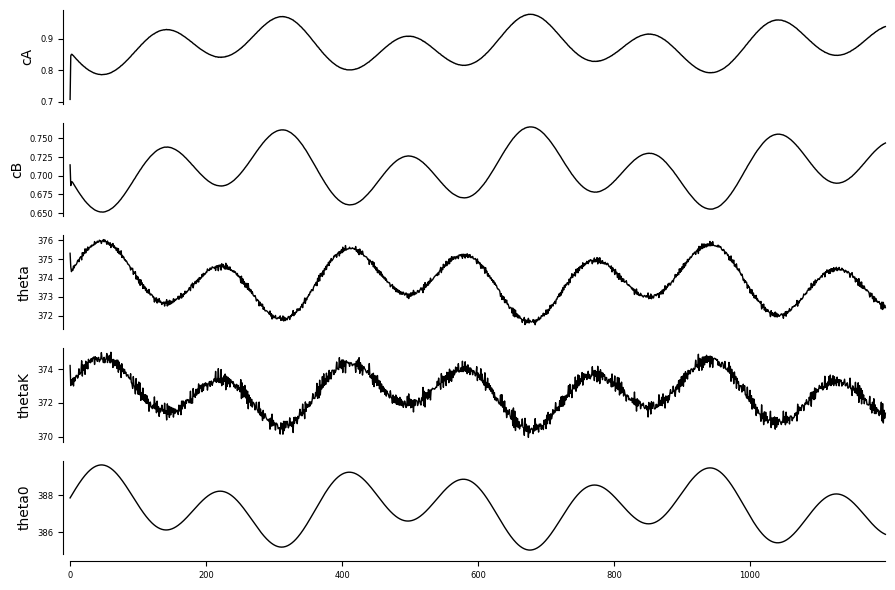

In [5]:
# Quick look at trajectories
tp.plot_timeseries(
    dataframe,
    figsize=(9, 6),
    grey_masked_samples=False,
    data_linewidth=1.0,
)
plt.show()

### Density plots (raw vs transformed)

To mirror the biogeoscience tutorial, this section overlays pairwise densities for:

- standardized raw data (red), and
- marginally Gaussian-transformed data (black).

This helps assess whether linear CI tests (ParCorr/RobustParCorr) are reasonable.


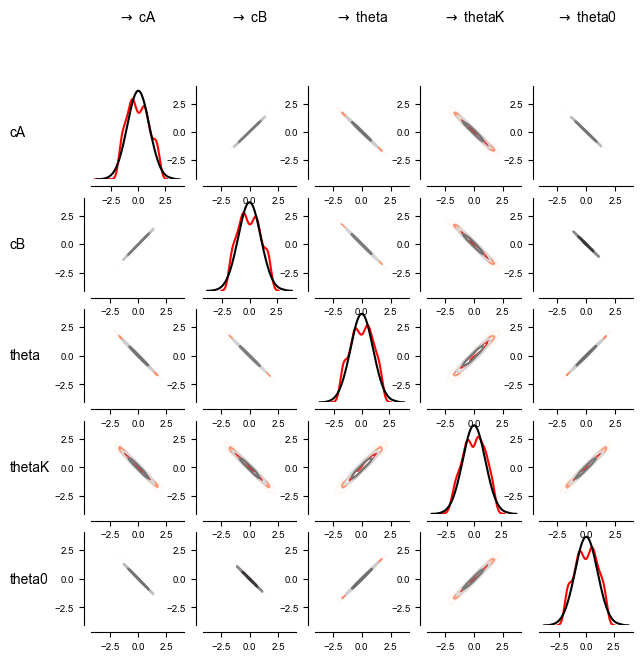

In [6]:
# Build density matrix plot similar to the biogeoscience case study
matrix = tp.setup_density_matrix(
    N=N,
    var_names=var_names,
    figsize=(7.0, 7.0),
    tick_label_size=7,
    label_space_left=0.16,
)

# 1) standardized raw data
data_std = {}
for m, arr in data_dict.items():
    mean = arr.mean(axis=0, keepdims=True)
    std = arr.std(axis=0, keepdims=True)
    std[std == 0.0] = 1.0
    data_std[m] = (arr - mean) / std

dataframe_std = pp.DataFrame(data_std, analysis_mode='multiple', var_names=var_names)
matrix.add_densityplot(
    dataframe=dataframe_std,
    matrix_lags=None,
    label_color='red',
    snskdeplot_args={'cmap': 'Reds', 'alpha': 1.0, 'levels': 4},
)

# 2) transformed to approximately Gaussian marginals
data_normal = {m: pp.trafo2normal(data_dict[m]) for m in data_dict}
dataframe_normal = pp.DataFrame(data_normal, analysis_mode='multiple', var_names=var_names)
matrix.add_densityplot(
    dataframe=dataframe_normal,
    matrix_lags=None,
    label_color='black',
    snskdeplot_args={'cmap': 'Greys', 'alpha': 1.0, 'levels': 4},
)


## Causal discovery analysis

We now apply sliding-window PCMCIplus to the sampled CSTR trajectories.

### Notes on assumptions

- **Differential equations are fine**: after sampling, we obtain a discrete-time multivariate process suitable for lagged causal discovery.
- We include $\vartheta_0$ as an observed exogenous variable.
- To reflect exogeneity, we forbid incoming links into $\vartheta_0$.

### Parametric assumptions

The CSTR equations are nonlinear, so linear-Gaussian assumptions can be violated.
We therefore:

1. Transform marginals to approximately Gaussian (`trafo2normal`) for linear CI tests.
2. Expose a CI-test switch so you can compare `ParCorr` vs `RobustParCorr`.
3. Default to `tau_min=1` (lagged-only) to avoid contemporaneous edges dominating the graph.


In [7]:
# ---------- Parametric-assumption handling ----------
# CI test options: 'parcorr' or 'robust_parcorr'
CI_TEST = 'parcorr'

# If True, transform each variable to approximately Gaussian marginals before PCMCI
USE_GAUSSIAN_MARGINAL_TRANSFORM = True

# If False, include contemporaneous links (tau=0).
ALLOW_CONTEMPORANEOUS = False

if USE_GAUSSIAN_MARGINAL_TRANSFORM:
    data_for_pcmci = {m: pp.trafo2normal(data_dict[m]) for m in data_dict}
    dataframe_pcmci = pp.DataFrame(data_for_pcmci, analysis_mode='multiple', var_names=var_names)
else:
    dataframe_pcmci = dataframe

if CI_TEST == 'parcorr':
    cond_ind_test = ParCorr(mask_type=None, verbosity=0)
elif CI_TEST == 'robust_parcorr':
    cond_ind_test = RobustParCorr(mask_type=None, verbosity=0)
else:
    raise ValueError("CI_TEST must be 'parcorr' or 'robust_parcorr'")

tau_min = 0 if ALLOW_CONTEMPORANEOUS else 1
print(f'Using CI test: {CI_TEST}, tau_min={tau_min}, Gaussian-transform={USE_GAUSSIAN_MARGINAL_TRANSFORM}')


Using CI test: parcorr, tau_min=1, Gaussian-transform=True


In [8]:
# Lag setup (dt = 1, so tau_max=2 captures short delays)
tau_max = 2

# Significance and sliding-window settings
pc_alpha = 0.01
window_step = 120
window_length = 360

theta0_idx = var_names.index("theta0")

# Structural constraint: theta0 is exogenous -> no incoming links to theta0.
link_assumptions_absent_link_means_no_knowledge = {j: {} for j in range(N)}
for i in range(N):
    for tau in range(0, tau_max + 1):
        if i == theta0_idx and tau == 0:
            continue
        link_assumptions_absent_link_means_no_knowledge[theta0_idx][(i, -tau)] = ""

link_assumptions = PCMCI.build_link_assumptions(
    link_assumptions_absent_link_means_no_knowledge=link_assumptions_absent_link_means_no_knowledge,
    n_component_time_series=N,
    tau_max=tau_max,
    tau_min=tau_min,
)


KeyError: (0, 0)

In [ ]:
pcmci = PCMCI(dataframe=dataframe_pcmci, cond_ind_test=cond_ind_test, verbosity=0)

method_args = {
    "tau_min": tau_min,
    "tau_max": tau_max,
    "pc_alpha": pc_alpha,
    "link_assumptions": link_assumptions,
}

summary_results = pcmci.run_sliding_window_of(
    method="run_pcmciplus",
    method_args=method_args,
    window_step=window_step,
    window_length=window_length,
    conf_lev=0.9,
)


In [ ]:
# Plot window-specific causal graphs
graphs = summary_results["window_results"]["graph"]

n_windows = len(graphs)
ncols = min(4, n_windows)
nrows = int(np.ceil(n_windows / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows))
axes = np.atleast_1d(axes).ravel()

for w, ax in enumerate(axes):
    if w < n_windows:
        tp.plot_graph(
            graph=graphs[w],
            var_names=var_names,
            node_size=0.35,
            node_label_size=9,
            arrow_linewidth=2.5,
            show_colorbar=False,
            fig_ax=(fig, ax),
        )
        ax.set_title(f"Window {w + 1}", fontsize=10)
    else:
        ax.axis("off")

fig.tight_layout()
plt.show()

### Aggregated causal graph

As in the biogeoscience case study, we summarize across windows using the most frequent links and their frequencies.

In [ ]:
val_tmp = np.abs(summary_results["summary_results"]["val_matrix_mean"])
val_tmp[np.arange(N), np.arange(N), :] = 0.0
cross_max = np.abs(val_tmp).max()

graph = summary_results["summary_results"]["most_frequent_links"]
link_width = summary_results["summary_results"]["link_frequency"]

fig, ax = tp.plot_graph(
    graph=graph,
    link_width=link_width,
    cmap_edges="RdBu_r",
    arrow_linewidth=4.0,
    node_size=0.4,
    var_names=var_names,
    vmin_edges=-max(0.2, cross_max),
    vmax_edges=max(0.2, cross_max),
    edge_ticks=0.5,
    node_ticks=0.5,
    show_colorbar=False,
    figsize=(4.5, 3.6),
)
plt.show()